<a href="https://colab.research.google.com/github/s006aj/DATA-SCIENCE-/blob/main/CLUSTERING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

LOADING AND PREPROCESSING

In [2]:
iris = load_iris(as_frame=True)
X = iris.data # Features: sepal length, sepal width, petal length, petal width

print("Dataset loaded successfully.")
print("Features used for clustering:\n", X.head())

Dataset loaded successfully.
Features used for clustering:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


K MEANS CLUSTRING

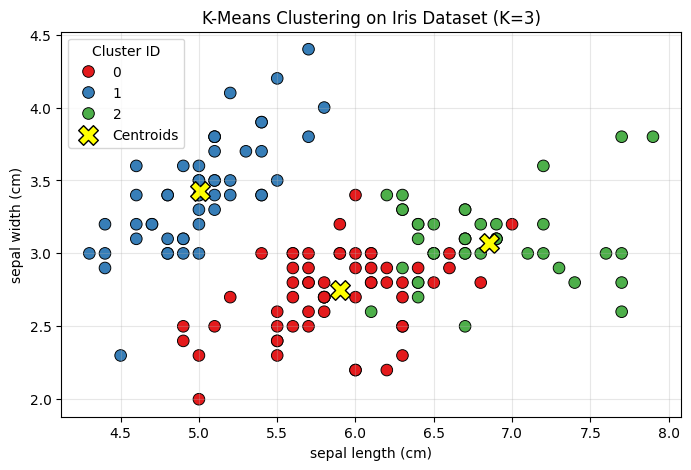

In [3]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)


plt.figure(figsize=(8, 5))
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=kmeans_labels, palette='Set1', s=70, edgecolor='k')


plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='yellow', marker='X', edgecolor='black', label='Centroids')

plt.title('K-Means Clustering on Iris Dataset (K=3)')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

K MEANS
K Means partitions data into K distinct, non-overlapping clusters. It starts by placing K random center points called centroids. Then, it repeats two steps until the centroids stop moving.it assigns each data point to its nearest centroid, and it recalculates the center of each cluster by averaging all the points assigned to it.

K-Means works well because  when clusters are spherical, compact, and well-separated in features. The physical dimensions of flower petals and sepals form distinct, continuous numerical boundaries that map perfectly to distance calculations.

HIERARCIAL CLUSTERING

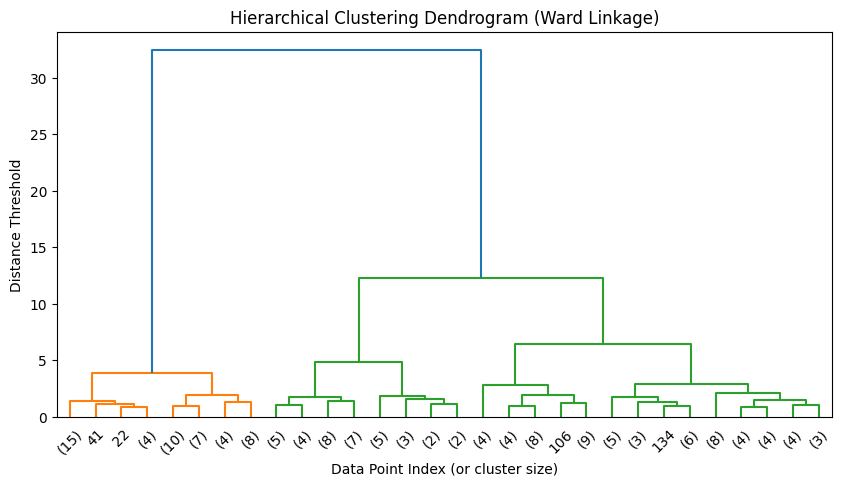

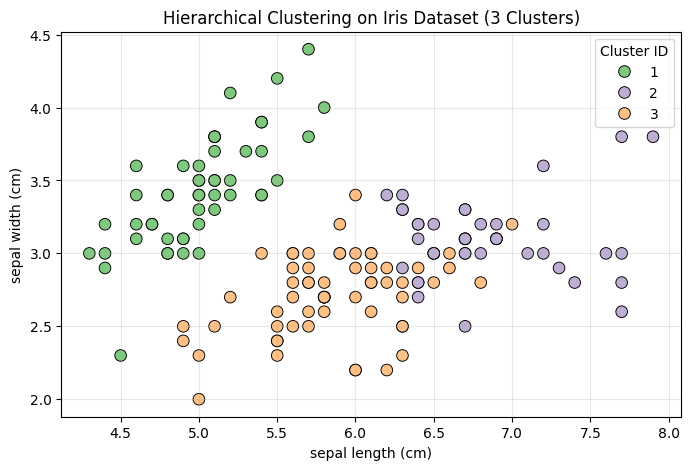

In [4]:

linked = linkage(X, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Data Point Index (or cluster size)')
plt.ylabel('Distance Threshold')
plt.show()
hierarchical_labels = fcluster(linked, t=3, criterion='maxclust')
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=hierarchical_labels, palette='Accent', s=70, edgecolor='k')
plt.title('Hierarchical Clustering on Iris Dataset (3 Clusters)')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

Hierarcheal clustering
Hierarchical clustering builds a tree like hierarchy of clusters called a dendrogram. We typically use the Agglomerative approach, which treats every single data point as its own tiny cluster at the start. It then iteratively finds and merges the two closest clusters together step by step until all points are joined into one massive cluster tree.

Hierarchical clustering is highly valuable for the Iris dataset because it is not requires  to guess the number of clusters in advance. It allows to inspect the dendrogram layout visually to reveal biological subspecies or hierarchical relationships between different plant traits.